In [1]:
import rasterio
import os
from glob import glob
import numpy as np 
import pandas as pd
from scipy import stats
from datetime import datetime
from rasterio.plot import reshape_as_image
from matplotlib import pyplot as pyplt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

def find_non_outliers_iqr(data_array):
    # Remove NaN values, as they can interfere with calculations
    cleaned_data = data_array[~np.isnan(data_array) & ~np.isinf(data_array)]

    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = np.percentile(cleaned_data, 25)
    Q3 = np.percentile(cleaned_data, 75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Define the upper and lower bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Identify outliers
    outliers = cleaned_data[(cleaned_data < lower_bound) | (cleaned_data > upper_bound)]

    total_valid = len(cleaned_data)
    percentage = len(outliers) / total_valid * 100
    print(f"Number of outliers: {len(outliers)} / {total_valid} ({percentage:.2f}%) valid data points")
    data_no_outliers_mask = (data_array >= lower_bound) & (data_array <= upper_bound)
    #print(f"data no outlier shape:{data_no_outliers_mask.shape}")
    return outliers, lower_bound, upper_bound, data_no_outliers_mask


In [3]:
def min_max_normalization(arr,mask):
    min_val = np.nanmin(arr[mask])
    max_val = np.nanmax(arr[mask])
    std = np.nanstd(arr[mask])
    mean = np.nanmean(arr[mask])
    median = np.nanmedian(arr[mask])
    mode = stats.mode(arr[mask])[0]
    print(f"In min-max: arr.shape: {arr.shape}")
    print(f"Before normalization:\n")
    print(f"min: {min_val}\nmax: {max_val}")
    print(f"std: {std}\nmean: {mean}\nmedian: {median}\nmode: {mode}")
    # Avoid division by zero if all values are the same
    if max_val == min_val:
        return np.zeros_like(arr[mask])
    
    arr[mask] = (2 * (arr[mask] - min_val) / (max_val - min_val)) - 1
    min_val = np.nanmin(arr[mask])
    max_val = np.nanmax(arr[mask])
    std = np.nanstd(arr[mask])
    mean = np.nanmean(arr[mask])
    arr[~mask] = np.nan
    print(f"After normalization:\n")
    print(f"min: {min_val}\nmax: {max_val}")
    print(f"std: {std}\nmean: {mean}")
    print(f"arr shape: {arr.shape}")
    return arr

In [4]:
def z_normalization(arr,mask):
    min_val = np.nanmin(arr[mask])
    max_val = np.nanmax(arr[mask])
    std = np.nanstd(arr[mask])
    mean = np.nanmean(arr[mask])
    median = np.nanmedian(arr[mask])
    mode = stats.mode(arr[mask])[0]
    print(f"Before normalization:\n")
    print(f"min: {min_val}\nmax: {max_val}")
    print(f"std: {std}\nmean: {mean}\nmedian: {median}\nmode: {mode}")
    arr[mask] = (arr[mask] - mean) / std
    arr[~mask] = np.nan
    min_val = np.nanmin(arr[mask])
    max_val = np.nanmax(arr[mask])
    std = np.nanstd(arr[mask])
    mean = np.nanmean(arr[mask])
    median = np.nanmedian(arr[mask])
    mode = stats.mode(arr[mask])[0]
    print(f"After normalization:\n")
    print(f"min: {min_val}\nmax: {max_val}")
    print(f"std: {std}\nmean: {mean}\nmedian: {median}\nmode: {mode}")

    return arr

In [5]:
def z_normalization_raw(arr):
    arr = np.where(np.isinf(arr), np.nan, arr)
    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)
    std = np.nanstd(arr)
    mean = np.nanmean(arr)
    median = np.nanmedian(arr)
    mode = stats.mode(arr)[0]
    print(f"Before normalization:\n")
    print(f"min: {min_val}\nmax: {max_val}")
    print(f"std: {std}\nmean: {mean}\nmedian: {median}\nmode: {mode}")
    arr = (arr - mean) / std
    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)
    std = np.nanstd(arr)
    mean = np.nanmean(arr)
    median = np.nanmedian(arr)
    mode = stats.mode(arr)[0]
    print(f"After normalization:\n")
    print(f"min: {min_val}\nmax: {max_val}")
    print(f"std: {std}\nmean: {mean}\nmedian: {median}\nmode: {mode}")

    return arr

In [6]:

def ndvi_conversion(tile_ID, date):
    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"
    with rasterio.open(selected_tile) as tile:
        profile = tile.profile
        profile.update(dtype = rasterio.float32, count=1)
        red = tile.read(3).astype(np.float32)
        nir = tile.read(7).astype(np.float32)
        np.seterr(divide="ignore", invalid="ignore")
        ndvi = (nir-red) / (nir + red)
        dir = "./ndvi"
        os.makedirs(dir, exist_ok=True)
        ndvi_path = f"./ndvi/ndvi_{tile_ID}_{date}_test.tif"
        with rasterio.open(ndvi_path, "w", **profile) as ndvi_file:
            ndvi_file.write(ndvi.astype(rasterio.float32)[np.newaxis, :, :])
    return ndvi

def gndvi_conversion(tile_ID, date):

    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        
        profile = tile.profile
        profile.update(dtype = rasterio.float32, count=1)

        green = tile.read(2).astype(np.float32)
        nir = tile.read(7).astype(np.float32)
        np.seterr(divide="ignore", invalid="ignore")

        gndvi = (nir - green) / (nir + green) 
        dir = "./gndvi"
        os.makedirs(dir, exist_ok=True)
        path = f"./gndvi/gndvi_{tile_ID}_{date}_test.tif"
        """with rasterio.open(path, "w", **profile) as file:
            file.write(gndvi.astype(rasterio.float32)[np.newaxis, :, :])"""
    return gndvi

def evi_conversion(tile_ID, date):

    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        
        profile = tile.profile
        profile.update(dtype = rasterio.float32, count=1)

        blue = tile.read(1).astype(np.float32) /10000
        red = tile.read(3).astype(np.float32) /10000
        nir = tile.read(7).astype(np.float32) /10000
        np.seterr(divide="ignore", invalid="ignore")

        evi = 2.5 * (nir - red) / (nir + 6 * red - 7.5 * blue + 1)
        outliers, lower_bound, upper_bound, evi_no_outliers_mask = find_non_outliers_iqr(evi)
        evi_normalized = z_normalization(evi,evi_no_outliers_mask)
        dir = "./evi"
        os.makedirs(dir, exist_ok=True)
        path = f"./evi/evi_{tile_ID}_{date}_native_z_score.tif"
        with rasterio.open(path, "w", **profile) as file:
            file.write(evi_normalized.astype(rasterio.float32)[np.newaxis, :, :])
    return evi

def ndwi_conversion(tile_ID, date):

    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        
        profile = tile.profile
        profile.update(dtype = rasterio.float32, count=1)

        green = tile.read(2).astype(np.float32)
        nir8a = tile.read(8).astype(np.float32)
        np.seterr(divide="ignore", invalid="ignore")

        ndwi = (green - nir8a) / (green + nir8a) 
        dir = "./ndwi"
        os.makedirs(dir, exist_ok=True)
        path = f"./ndwi/ndwi_{tile_ID}_{date}_test.tif"
        """with rasterio.open(path, "w", **profile) as file:
            file.write(ndwi.astype(rasterio.float32)[np.newaxis, :, :])"""
    return ndwi

def ndbi_conversion(tile_ID, date):

    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        
        profile = tile.profile
        profile.update(dtype = rasterio.float32, count=1)

        nir = tile.read(7).astype(float)
        swir = tile.read(9).astype(float)
        np.seterr(divide="ignore", invalid="ignore")

        ndbi = (swir - nir) / (swir + nir) 
        dir = "./ndbi"
        os.makedirs(dir, exist_ok=True)
        path = f"./ndbi/ndbi_{tile_ID}_{date}_test.tif"
        """with rasterio.open(path, "w", **profile) as ndvi_file:
            ndvi_file.write(ndbi.astype(rasterio.float32)[np.newaxis, :, :])"""
    return ndbi

def msavi_conversion(tile_ID, date):

    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        profile = tile.profile
        profile.update(dtype=rasterio.float32, count=1)

        # Sentinel-2 bands
        red = tile.read(3).astype(float) 
        nir = tile.read(7).astype(float)  

        np.seterr(divide="ignore", invalid="ignore")

        # MSAVI formula
        msavi = (2 * nir + 1 - np.sqrt((2 * nir + 1)**2 - 8 * (nir - red))) / 2

        # Optional: save to file
        dir = "./msavi"
        os.makedirs(dir, exist_ok=True)
        path = f"./msavi/msavi_{tile_ID}_{date}.tif"
        """with rasterio.open(path, "w", **profile) as msavi_file:
            msavi_file = msavi.astype(rasterio.float32)
            msavi_file = msavi[np.newaxis, :, :]
            msavi_file.write(msavi_file)"""

    return msavi

def lai_conversion(tile_ID, date, evi):
    """
    Compute LAI from an already computed EVI array.
    LAI = 3.618 * EVI - 0.118
    """

    # Apply LAI formula
    lai = (3.618 * evi) - 0.118

    # Optional: save to file
    dir = "./lai"
    os.makedirs(dir, exist_ok=True)
    path = f"./lai/lai_{tile_ID}_{date}.tif"

    """with rasterio.open(path, "w", **profile) as lai_file:
        lai_data = lai.astype(rasterio.float32)
        lai_data = lai_data[np.newaxis, :, :]
        lai_file.write(lai_data)"""

    return lai

def ndmi_conversion(tile_ID, date):
    """
    Compute NDMI from a Sentinel-2 tile.
    NDMI = (NIR - SWIR) / (NIR + SWIR)
    """

    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        profile = tile.profile
        profile.update(dtype=rasterio.float32, count=1)

        # Sentinel-2 bands (example: Band 8 = NIR, Band 11 = SWIR)
        nir = tile.read(7).astype(float)  
        swir = tile.read(9).astype(float) 

        np.seterr(divide="ignore", invalid="ignore")

        # NDMI formula
        ndmi = (nir - swir) / (nir + swir)

        # Optional: save to file
        dir = "./ndmi"
        os.makedirs(dir, exist_ok=True)
        path = f"./ndmi/ndmi_{tile_ID}_{date}.tif"
        """
        with rasterio.open(path, "w", **profile) as ndmi_file:
            ndmi_data = ndmi.astype(rasterio.float32)
            ndmi_data = ndmi_data[np.newaxis, :, :]
            ndmi_file.write(ndmi_data)
        """

    return ndmi

def mtci_conversion(tile_ID, date):
    """For Sentinel-2 the formula is (B6 - B5)/(B5 - B4), 
    where (Central wavelength/Bandwidth): B6 = 740 nm (15 nm), B5 = 705 nm (15 nm), B4 = 665 nm (30 nm)"""
    
    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        profile = tile.profile
        profile.update(dtype=rasterio.float32, count=1)

        red_b4 = tile.read(3).astype(float)        # Band 4
        red_edge_b5 = tile.read(4).astype(float)  # Band 5
        red_edge_b6 = tile.read(5).astype(float)        # Band 6

        np.seterr(divide="ignore", invalid="ignore")

        # MTCI formula
        mtci = (red_edge_b6- red_edge_b5) / (red_edge_b5 - red_b4)

        # Optional: save to file
        dir = "./mtci"
        os.makedirs(dir, exist_ok=True)
        path = f"./mtci/mtci_{tile_ID}_{date}.tif"
        """
        with rasterio.open(path, "w", **profile) as mtci_file:
            mtci_data = mtci.astype(rasterio.float32)
            mtci_data = mtci_data[np.newaxis, :, :]
            mtci_file.write(mtci_data)
        """

    return mtci

def swir_conversion(tile_ID, date):
    
    selected_tile = f"./S2_data/{tile_ID}_{date}.tif"

    with rasterio.open(selected_tile) as tile:
        profile = tile.profile
        profile.update(dtype=rasterio.float32, count=1)

        swir = tile.read(9).astype(float) / 10000     

        np.seterr(divide="ignore", invalid="ignore")

        dir = "./swir"
        os.makedirs(dir, exist_ok=True)
        path = f"./swir/swir_{tile_ID}_{date}.tif"
        
        with rasterio.open(path, "w", **profile) as swir_file:
            swir_data = swir.astype(rasterio.float32)
            swir_data = swir_data[np.newaxis, :, :]
            swir_file.write(swir_data)

    return swir

In [7]:

def heatmap(lu_code, label_arr, ndvi_arr, ndwi_arr, ndbi_arr, evi_arr, num_points = 1000):
    lu_code = 2101
    stats = {}
    indices = np.where((label_arr == lu_code) & (~np.isnan(ndvi_arr)) & (~np.isnan(ndwi_arr)) & (~np.isnan(ndbi_arr)) & (~np.isnan(ndbi_arr)) & (~np.isnan(evi_arr)) & (~np.isinf(evi_arr)))
    evi_filtered = evi_arr[indices]
    evi_morethan1 = evi_filtered[evi_filtered > 1]
    print(evi_morethan1)
    count = np.sum(evi_filtered > 1)
    print(f"count : {count}")
    sampled_points = []
    for _ in range(min(num_points, len(indices[0]))):
        rand_idx = np.random.randint(0, len(indices[0]))
        i, j = indices[0][rand_idx], indices[1][rand_idx]
        sampled_points.append({
            "NDVI": ndvi_arr[i, j],
            "NDWI": ndwi_arr[i, j],
            "NDBI": ndbi_arr[i, j],
            "EVI": evi_arr[i,j]
        })

    #print(sampled_points)
    df = pd.DataFrame(sampled_points)
    #print(df.head(10))
    correlation_matrix = df.corr()
    #print(correlation_matrix.head(10))
    plt.figure(figsize = (10,8))
    sns.heatmap(correlation_matrix, cmap = 'coolwarm')
    plt.show()
    
    return stats


In [8]:
def get_lu_code(selected_crop):
    df = pd.read_excel("LUCODE.xls", sheet_name="ตารางที่ 2", header=1)
    matches = df.loc[df['LU_DES_EN'].isin(selected_crop),['LU_ID_L3','LU_DES_EN','LU_DES_TH']]
    crop_lu_code = matches["LU_ID_L3"].values
    return crop_lu_code, matches

def get_label_arr(label_path):
    with rasterio.open(label_path) as label:
        label_arr = label.read(1)
    return label_arr

In [9]:
def visualize_outliers_iqr(data_array, outliers, lower_bound, upper_bound):

    # Flatten the array for the box plot
    flat_data = data_array.flatten()

    plt.figure(figsize=(12, 6))
    sns.boxplot(x=flat_data)
    plt.xlim(-2, 2)
    plt.title('Outlier Detection with IQR Method', fontsize=16)
    plt.xlabel('Values', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    # Add lines for the IQR boundaries
    plt.axvline(x=lower_bound, color='red', linestyle='--', label=f'Lower Bound: {lower_bound:.2f}')
    plt.axvline(x=upper_bound, color='red', linestyle='--', label=f'Upper Bound: {upper_bound:.2f}')
    
    # Highlight the outliers on the plot
    if outliers.size > 0:
        plt.plot(outliers, np.zeros_like(outliers), 'o', color='red', markersize=10, label='Outliers')

    plt.legend()
    plt.show()

In [23]:

tile_ID = "47PQQ"
date = "2018-11-30"

month = datetime.strptime(date, "%Y-%m-%d").month
year = datetime.strptime(date, "%Y-%m-%d").year

tile_path = f"./S2_data/{tile_ID}_{date}.tif"
label_path = f"./label/label_{tile_ID}_{year}.tif"

crop = ["Active paddy field", "Pineapple", "Cassava", "Durian", "Mangosteen", "Rambutan", "Langsat", "Jack fruit", "Mango", "Coconut", "Para rubber", "Oil palm", "Longan", "Reservoir"]

lu_code, lu_with_names = get_lu_code(crop)
label_arr = get_label_arr(label_path)
ndvi_arr = ndvi_conversion(tile_ID,date)
ndwi_arr = ndwi_conversion(tile_ID,date)
evi_arr = evi_conversion(tile_ID,date)
mtci_arr = mtci_conversion(tile_ID,date)
swir_arr = swir_conversion(tile_ID,date)
#ndmi_arr = ndmi_conversion(tile_ID, date)
#heatmap(lu_code, label_arr, ndvi_arr, ndwi_arr,ndbi_arr,evi_arr)

Number of outliers: 32228 / 120560399 (0.03%) valid data points


MemoryError: Unable to allocate 196. MiB for an array with shape (25705585,) and data type int64

In [ ]:
labels_flat = label_arr.flatten()
ndvi_flat = ndvi_arr.flatten()
evi_flat = evi_arr.flatten()
ndwi_flat = ndwi_arr.flatten()
mtci_flat = mtci_arr.flatten()
swir_flat = swir_arr.flatten()

df = pd.DataFrame({
    "label": labels_flat,
    "ndvi 11": ndvi_flat,
    "evi 11": evi_flat,
    "ndwi 11": ndwi_flat,
    "mtci 11": mtci_flat,
    "swir 11": swir_flat
})
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.shape
# Drop rows that have any NaN (which now also includes Inf)


(120560400, 6)

In [ ]:
df = df[df["label"] != 0]
df = df.round(3)
df

,label,ndvi 10,evi 10,ndwi 10,mtci 10,swir 10
47519270,3101,0.816,1.450,-0.461,2.807,0.093
47519271,3101,0.793,1.230,-0.492,2.925,0.093
47519272,3101,0.794,1.246,-0.491,2.698,0.098
47519273,3101,0.815,1.332,-0.479,2.516,0.098
47519274,3101,0.820,1.420,-0.448,3.087,0.093
...,...,...,...,...,...,...
120556140,1602,-0.141,-1.733,0.221,-2.982,0.063
120556141,1602,-0.153,-1.747,0.201,-1.608,0.063
120556142,4103,-0.149,-1.761,0.268,-2.400,0.062
120556143,4103,-0.153,-1.804,0.334,-3.000,0.062


In [ ]:

df= df[~df['label'].astype(str).str.startswith('1')]


In [ ]:
df.loc[~df["label"].isin(lu_code), "label"] = 9999
df.shape

(30971413, 6)

In [15]:
df_sampled = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 400000), replace=False, random_state=42)
)

C:\Users\user\AppData\Local\Temp\ipykernel_22996\2049142762.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('label', group_keys=False).apply(


In [22]:
df_sampled

,label,ndvi 10,evi 10,ndwi 10,mtci 10,swir 10
98850875,2101,0.646,0.297,-0.316,1.692,0.088
96486439,2101,0.738,0.329,-0.374,2.016,0.074
98835770,2101,0.413,-0.154,-0.249,2.389,0.143
95750370,2101,0.809,0.925,-0.405,2.781,0.078
96551884,2101,0.826,0.902,-0.420,3.135,0.067
...,...,...,...,...,...,...
78956067,9999,0.821,0.506,-0.480,2.889,0.053
90132814,9999,0.199,-0.852,-0.230,5.893,0.141
77605189,9999,0.723,0.392,-0.518,4.495,0.087
92827523,9999,0.871,1.053,-0.578,3.952,0.075


In [ ]:
df_10 = pd.read_csv("2018_10_3000000_mtci+swir_no_shrunk.csv")

sampled_indices = df_10['Unnamed: 0'].tolist()
df_10['Unnamed: 0'].shape

(3145251,)

In [ ]:
df_sampled = df.loc[sampled_indices]
df_sampled

,label,ndvi 12,evi 12,ndwi 12,mtci 12,swir 12
103637848,2101,0.682,0.314,-0.385,1.600,0.069
100213662,2101,0.235,-0.789,-0.573,0.770,0.287
98835837,2101,0.215,-0.918,-0.359,0.553,0.143
92522687,2101,0.309,-0.779,-0.484,0.557,0.141
112221477,2101,0.645,0.321,-0.514,2.039,0.116
...,...,...,...,...,...,...
92633226,9999,0.852,1.131,-0.568,3.145,0.081
103887753,9999,0.678,0.435,-0.564,2.972,0.114
101003973,9999,0.594,0.765,-0.295,2.090,0.092
53766899,9999,NaN,-1.504,NaN,NaN,0.000


In [ ]:
df_sampled.to_csv("2018_11_3000000_mtci+swir_no_shrunk.csv", encoding="utf-8-sig")

In [ ]:
df_10 = pd.read_csv("2018_10_3000000_mtci+swir_no_shrunk.csv")
df_11 = pd.read_csv("2018_11_3000000_mtci+swir_no_shrunk.csv")
df_12 = pd.read_csv("2018_12_3000000_mtci+swir_no_shrunk.csv")

In [35]:
df_2024 = pd.concat([df_10.iloc[:, 1:], df_11.iloc[:, 2:],df_12.iloc[:, 2:]],axis=1)
df_all = df_2024.reset_index(drop=True)
#df_all.drop(columns=["mtci 10", "mtci 11", "mtci 12"])
df_all.to_csv("2018_3000000_mtci+swir.csv", encoding="utf-8-sig")


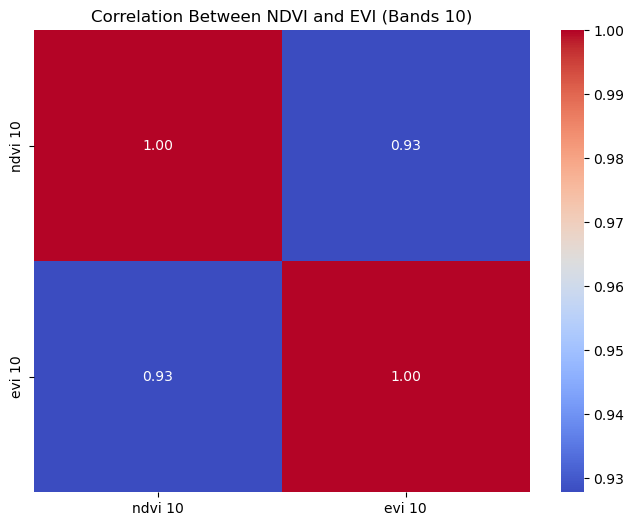

In [19]:
df = pd.read_csv("2024-10_52500.csv")
df = df.dropna()
df_compare = df.drop(columns=(['Unnamed: 0','label','ndbi 10','ndwi 10']))
corr = df_compare.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between NDVI and EVI (Bands 10)")
plt.show()

let [lowerbound, upperbound], number of values in the range [-0.39964014401358566, 1.1288443422388625]: 120527957 from 120560400 (10980 * 10980)


While minimizing much of the contamination problems present in the NDVI, such as those associated with canopy background and residual aerosol influences. Whereas the NDVI is chlorophyll sensitive and responds mostly to red band variations, the EVI is more NIR sensitive and responsive to canopy structural variations, including leaf area index, canopy type, and canopy architecture.

In [37]:
df = pd.read_csv("2024_110000_with_outliers.csv", encoding="utf-8-sig")
label_counts = df['label'].value_counts()

print(label_counts)

label
2101    8000
2204    8000
2205    8000
2302    8000
2303    8000
2403    8000
2405    8000
2407    8000
2413    8000
2416    8000
2419    8000
4201    8000
9999    8000
2404    5011
2420    1573
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. List of indices to plot
indices = ["swir"]

for idx in indices:
    plt.figure(figsize=(8,4))
    sns.stripplot(x="label", y=idx, data=df_sampled, jitter=True)
    plt.title(f"Scatter of {idx} per label")
    plt.xlabel("Label")
    plt.ylabel(idx.upper())
    plt.show()

In [1]:
import pandas as pd
df_2020 = pd.read_csv("2020_3000000_mtci+swir.csv")
df_2024 = pd.read_csv("2024_350000_mtci+swir.csv")
labels = [2404, 2405, 2407, 2413, 2416, 2419, 2420]
subset = df_2020[df_2020["label"].isin(labels)]
subset = subset.drop(columns="Unnamed: 0")


In [12]:
subset.shape

(148940, 16)

In [10]:
df_combined_small_class = pd.concat([df_2024, subset], axis=0)

In [11]:
df_combined_small_class.shape

(499327, 17)

In [13]:
df_combined_small_class.to_csv('2020_and_2024_350000_for_small_class.csv')

In [7]:
import pandas as pd

# Load your CSV
df = pd.read_csv("2020_3000000_mtci+swir.csv", encoding="utf-8-sig")

# ✅ Filter rows where 'label' is one of the specified values
filtered_df = df[df["label"].isin([2101, 2204, 2205, 2302, 2303, 2403, 4201, 9999])]

# (Optional) Display or save
filtered_df.head()# to preview
#filtered_df.to_csv("No_small_classes_2020_3000000_mtci+swir.csv", index=False, encoding="utf-8-sig")




,Unnamed: 0,label,ndvi 10,evi 10,ndwi 10,mtci 10,swir 10,ndvi 11,evi 11,ndwi 11,mtci 11,swir 11,ndvi 12,evi 12,ndwi 12,mtci 12,swir 12
0,0,2101,0.837,1.357,-0.593,3.108,0.077,0.820,0.792,-0.547,3.208,0.085,0.835,0.663,-0.626,2.310,0.080
1,1,2101,0.490,0.776,-0.374,2.505,0.136,0.469,0.086,-0.347,4.386,0.149,0.432,-0.019,-0.371,5.704,0.152
2,2,2101,NaN,-0.715,NaN,NaN,0.000,NaN,-1.490,NaN,NaN,0.000,0.731,0.470,-0.593,2.114,0.101
3,3,2101,NaN,-0.715,NaN,NaN,0.000,0.531,0.247,-0.266,1.245,0.120,0.261,-0.840,-0.397,1.079,0.130
4,4,2101,NaN,-0.715,NaN,NaN,0.000,0.502,-0.197,-0.472,0.569,0.150,0.468,-0.292,-0.492,0.741,0.160


In [13]:
filtered_df.head()
#filtered_df.to_csv("No_small_classes_2020_3000000_mtci+swir.csv", index=False, encoding="utf-8-sig")


,label,ndvi 10,evi 10,ndwi 10,mtci 10,swir 10,ndvi 11,evi 11,ndwi 11,mtci 11,swir 11,ndvi 12,evi 12,ndwi 12,mtci 12,swir 12
0,2101,0.837,1.357,-0.593,3.108,0.077,0.820,0.792,-0.547,3.208,0.085,0.835,0.663,-0.626,2.310,0.080
1,2101,0.490,0.776,-0.374,2.505,0.136,0.469,0.086,-0.347,4.386,0.149,0.432,-0.019,-0.371,5.704,0.152
2,2101,NaN,-0.715,NaN,NaN,0.000,NaN,-1.490,NaN,NaN,0.000,0.731,0.470,-0.593,2.114,0.101
3,2101,NaN,-0.715,NaN,NaN,0.000,0.531,0.247,-0.266,1.245,0.120,0.261,-0.840,-0.397,1.079,0.130
4,2101,NaN,-0.715,NaN,NaN,0.000,0.502,-0.197,-0.472,0.569,0.150,0.468,-0.292,-0.492,0.741,0.160
